# Notebook 2: Premier League player market value

Give it a player and a season of output, get back what they are worth.

This one also feeds back into notebook 1. Market value is a better measure of
how much a player matters than minutes and goals are, so once this works it
drops straight into the news branch and makes that smarter too.

### Two things that decide whether this works

**The target has to be logged.** Values run from roughly 25,000 euros to over
200 million. A model trained on raw euros spends everything it has on the
handful of superstars and cannot tell a 500k player from a 5m one, which is a
fivefold difference that matters enormously to a real club.

**Last year's value is a trap.** It is by far the strongest single predictor,
because Transfermarkt's numbers move slowly and are anchored to their own
history. Include it and you get a model that scores brilliantly and has learned
nothing about football. We train both versions and compare them, because the
gap between them is the actual finding.

### What good looks like

Market value is a crowd estimate, not a fact, so there is no true number to hit.
Landing within 25 percent of Transfermarkt on most players is solid. Anything
claiming near-perfect accuracy has leaked the previous valuation.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from src.config import INTERIM_DIR, PROCESSED_DIR, MODELS_DIR
from src import market as M
from src import features as F

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 4)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("ready")

ready


## 1. Build the dataset

Everything comes from Transfermarkt's own tables, joined on `player_id`. No
name matching anywhere in the core pipeline, which means no silent row loss.

The valuation for each player season is the one Transfermarkt published closest
to the end of that season, found with a backward-only `merge_asof` so it can
never pick up a number published afterwards.

The Elo ratings from notebook 1 come in as club strength, matched to the season
the player was actually there. Same output at a better club is worth more, and
this is how the model learns that.

In [2]:
# Club strength from notebook 1.
feat_path = PROCESSED_DIR / "matches_features.csv"
if feat_path.exists():
    matches_feat = pd.read_csv(feat_path, parse_dates=["date"])
    # Per season, not the final table. Using today's Elo for a 2013
    # player explains the past with the future.
    club_elo = F.season_elo_table(matches_feat)
    print(f"club Elo for {club_elo['team'].nunique()} clubs "
          f"across {club_elo['season_start'].nunique()} seasons")
else:
    club_elo = None
    print("No matches_features.csv. Run notebook 1 first for the Elo feature.")

club Elo for 44 clubs across 20 seasons


In [3]:
# Optional xG from FBref. Checks every table and says plainly if none
# of them carry an xG column.
fbref = [pd.read_csv(INTERIM_DIR / f"players_{t}.csv", low_memory=False)
         for t in ("standard", "shooting")
         if (INTERIM_DIR / f"players_{t}.csv").exists()]

df = M.build(first_season=2012, club_elo=club_elo, fbref=fbref)

print(f"\n{len(df):,} player seasons")
print(f"{df['player'].nunique():,} distinct players")
print(f"seasons {df['season_start'].min()} to {df['season_start'].max()}")
df[["player", "club", "season_start", "age", "minutes", "goals",
    "assists", "market_value_eur"]].head(10)

  No xG column in any FBref table. Continuing without xG.
  Your FBref scrape only offered basic stat types, so this is expected.

7,165 player seasons
2,319 distinct players
seasons 2012 to 2025


,player,club,season_start,age,minutes,goals,assists,market_value_eur
0,Aaron Hughes,Fulham,2012,33.508556,2115,0,0,1500000.0
1,Aaron Lennon,Tottenham Hotspur,2012,26.091718,2837,4,8,16000000.0
2,Aaron Ramsey,Arsenal,2012,22.395619,2086,1,4,10000000.0
3,Abou Diaby,Arsenal,2012,26.847365,713,0,0,4000000.0
4,Adam Federici,Reading,2012,28.177960,1890,0,0,2000000.0
5,Adam Johnson,Sunderland,2012,25.848049,2939,5,9,15000000.0
6,Adam Lallana,Southampton,2012,25.023956,2239,3,6,5500000.0
7,Adam Le Fondre,Reading,2012,26.461328,1495,12,2,2500000.0
8,Adel Taarabt,Queens Park Rangers,2012,23.967146,2245,5,5,10000000.0
9,Adrian Mariappa,Reading,2012,26.611910,2610,1,0,3000000.0


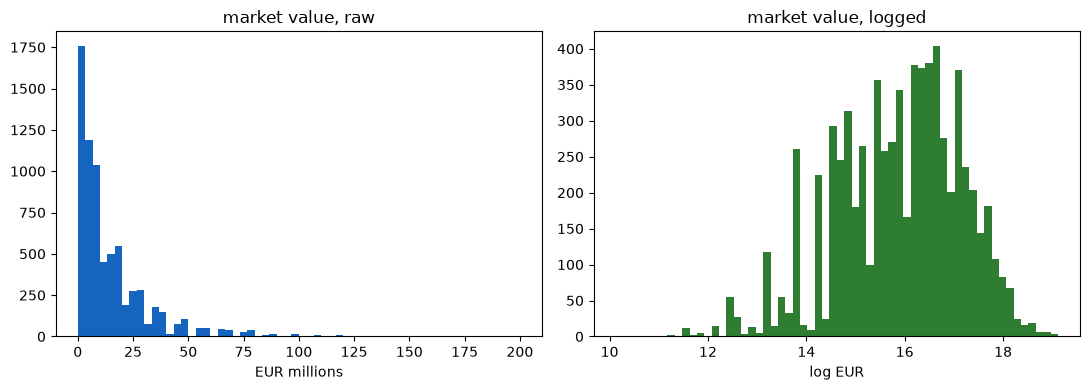

The left panel is why we log it. Almost every player is crushed into
the first bar while a few superstars stretch the axis to the right.
The right panel is something a model can actually learn from.

count        EUR 7k
mean      EUR 15.3m
std       EUR 18.3m
min         EUR 25k
25%        EUR 3.5m
50%        EUR 9.0m
75%       EUR 20.0m
max      EUR 200.0m


In [4]:
# What does the target actually look like?
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["market_value_eur"] / 1e6, bins=60, color="#1565c0")
axes[0].set_title("market value, raw"); axes[0].set_xlabel("EUR millions")
axes[1].hist(df["log_value"], bins=60, color="#2e7d32")
axes[1].set_title("market value, logged"); axes[1].set_xlabel("log EUR")
plt.tight_layout(); plt.show()

print("The left panel is why we log it. Almost every player is crushed into")
print("the first bar while a few superstars stretch the axis to the right.")
print("The right panel is something a model can actually learn from.\n")
print(df["market_value_eur"].describe().apply(M.euros).to_string())

### The age curve

Worth plotting before modelling, because it explains why `age_squared` is in
the feature list. Value is not a straight line in age: it climbs through the
early twenties, peaks somewhere around 24 to 26, and falls off steeply after
29. A linear term alone cannot represent that shape.

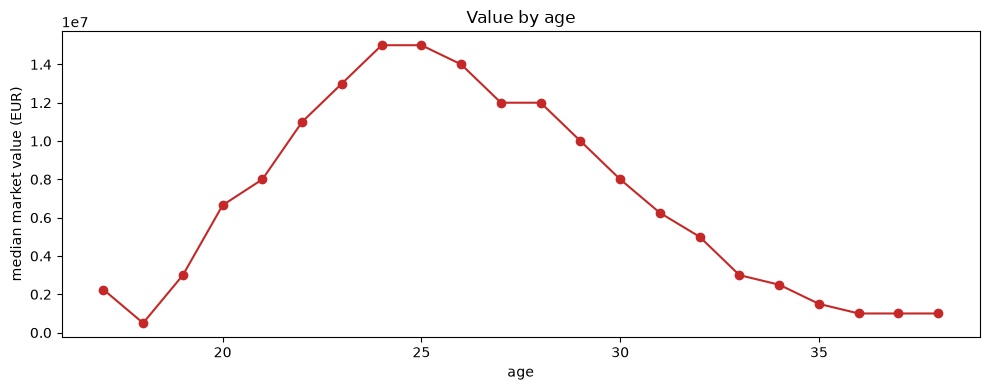

Median value peaks at age 24 in this data.


In [5]:
by_age = df[df["age"].between(17, 38)].groupby(df["age"].round())["market_value_eur"]
summary = by_age.median()

ax = summary.plot(marker="o", color="#c62828")
ax.set_xlabel("age"); ax.set_ylabel("median market value (EUR)")
ax.set_title("Value by age")
plt.tight_layout(); plt.show()

peak = summary.idxmax()
print(f"Median value peaks at age {peak:.0f} in this data.")

## 2. Split

By season again, for the same reason as notebook 1. A random split would let
the model see a player's 2025 valuation while training on their 2024 one, and
since Transfermarkt values move slowly that is close to handing it the answer.

In [6]:
TEST_SEASON = int(df["season_start"].max())
VAL_SEASONS = [TEST_SEASON - 2, TEST_SEASON - 1]

train = df[df["season_start"] < min(VAL_SEASONS)]
val   = df[df["season_start"].isin(VAL_SEASONS)]
test  = df[df["season_start"] == TEST_SEASON]

print(f"train {len(train):,}  val {len(val):,}  test {len(test):,}")
print(f"test season: {TEST_SEASON}/{(TEST_SEASON+1)%100:02d}")

train 5,550  val 1,096  test 519
test season: 2025/26


## 3. Transfer inflation

This is the single biggest thing standing between a raw model and a useful one.

The median Premier League valuation roughly quintupled between 2012 and 2025. A
model trained on seasons up to 2022 and tested on 2025 is being asked to price
players in a market a third more expensive than anything it has seen. Tree
models cannot extrapolate, so XGBoost treats a 2025 player as though prices
stopped moving in 2022, and underprices everyone.

The fix is to stop predicting euros and predict relative value instead: how
expensive is this player compared to a typical player in the same season? That
number is stable across years. Convert back to euros by adding the season's
market level.

One detail keeps this honest. The market level is built only from training and
validation seasons. The test season's level is extrapolated from the trend, so
no test valuation leaks into anything. In real use you would simply know the
current market, but extrapolating is the stricter test.

extrapolated 2025/26 market level: EUR 19.6m
actual median that season:            EUR 20.0m
(the model never sees the second number)


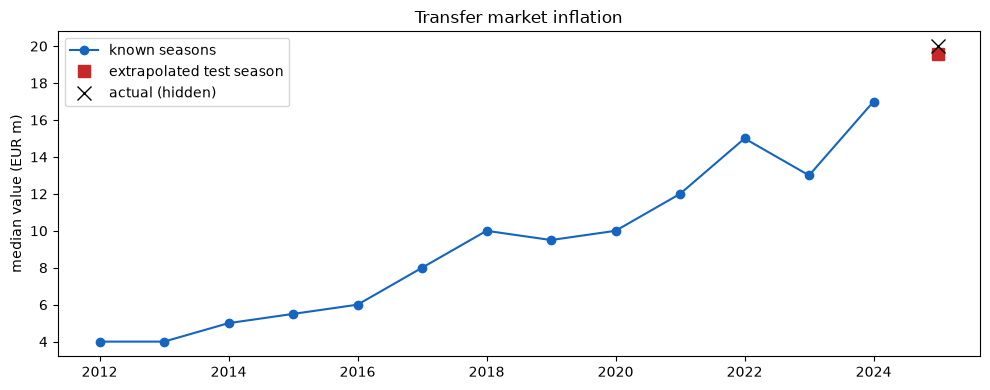

In [7]:
KNOWN_SEASONS = sorted(set(train["season_start"]) | set(val["season_start"]))
df_rel, INDEX = M.add_relative_target(df, KNOWN_SEASONS)

train, val, test = (df_rel.loc[p.index] for p in (train, val, test))

TEST_INDEX = test["market_index"].to_numpy()
TEST_LOG = test["log_value"].to_numpy()

actual_test = np.exp(df[df["season_start"] == TEST_SEASON]["log_value"].median())
print(f"extrapolated {TEST_SEASON}/{(TEST_SEASON+1)%100:02d} market level: "
      f"{M.euros(np.exp(TEST_INDEX[0]))}")
print(f"actual median that season:            {M.euros(actual_test)}")
print("(the model never sees the second number)")

yrs = np.array(INDEX.index, dtype=float)
plt.plot(yrs, np.exp(INDEX.values) / 1e6, "o-", color="#1565c0", label="known seasons")
plt.plot([TEST_SEASON], [np.exp(TEST_INDEX[0]) / 1e6], "s", color="#c62828",
         markersize=9, label="extrapolated test season")
plt.plot([TEST_SEASON], [actual_test / 1e6], "x", color="black",
         markersize=10, label="actual (hidden)")
plt.ylabel("median value (EUR m)"); plt.title("Transfer market inflation")
plt.legend(); plt.tight_layout(); plt.show()

In [8]:
def to_log(pred_rel):
    """Relative prediction back to absolute log value for the test season."""
    return np.asarray(pred_rel) + TEST_INDEX


def report(pred_rel):
    return M.error_report(TEST_LOG, to_log(pred_rel))

In [9]:
def prepare(include_prev_value, target="log_value_rel"):
    X_all, cols = M.feature_matrix(df_rel, include_prev_value=include_prev_value)
    med = X_all.loc[train.index].median()
    X_all = X_all.fillna(med)

    out = {}
    for name, part in (("train", train), ("val", val), ("test", test)):
        out[name] = (X_all.loc[part.index].to_numpy(dtype=np.float32),
                     part[target].to_numpy(dtype=np.float32))
    return out, cols

honest, cols_honest = prepare(include_prev_value=False)
leaky,  cols_leaky  = prepare(include_prev_value=True)

# The old approach, kept only to show what the inflation fix bought.
absolute, _ = prepare(include_prev_value=False, target="log_value")

print(f"without previous value: {len(cols_honest)} features")
print(f"with previous value:    {len(cols_leaky)} features")

without previous value: 26 features
with previous value:    27 features


## 4. Baselines

Two of them, and the first is deliberately stupid. Predicting the median value
for a player's position and age bracket is what you could do with a lookup
table and no model at all. Anything that cannot beat it is not earning its
keep.

In [10]:
# Lookup table baseline: median log value by position and age band.
tr = train.copy()
tr["age_band"] = pd.cut(tr["age"], [15, 21, 24, 27, 30, 45])
lookup = tr.groupby(["pos_group", "age_band"], observed=True)["log_value_rel"].median()
overall = tr["log_value_rel"].median()

te = test.copy()
te["age_band"] = pd.cut(te["age"], [15, 21, 24, 27, 30, 45])
naive = [lookup.get((p, a), overall)
         for p, a in zip(te["pos_group"], te["age_band"])]

BASE = report(np.array(naive))
print("Position and age lookup table")
for k, v in BASE.items():
    print(f"  {k}: {v:.3f}")

Position and age lookup table
  median_ape: 0.511
  mean_ape: 2.251
  median_abs_error_eur: 9117420.285
  within_25pct: 0.266
  within_50pct: 0.489
  log_rmse: 1.046
  log_r2: 0.253


In [11]:
def fit_ridge(data, label):
    (X_tr, y_tr), (X_te, y_te) = data["train"], data["test"]
    sc = StandardScaler().fit(X_tr)
    model = Ridge(alpha=1.0).fit(sc.transform(X_tr), y_tr)
    pred = model.predict(sc.transform(X_te))
    rep = report(pred)
    print(f"{label}:  median error {rep['median_ape']:.1%}   "
          f"within 25% {rep['within_25pct']:.1%}   log R2 {rep['log_r2']:.3f}")
    return rep

print("Ridge regression")
RIDGE_HONEST = fit_ridge(honest, "  without previous value")
RIDGE_LEAKY  = fit_ridge(leaky,  "  with previous value   ")

Ridge regression
  without previous value:  median error 37.2%   within 25% 30.3%   log R2 0.640
  with previous value   :  median error 25.2%   within 25% 49.7%   log R2 0.728


## 5. Gradient boosting

On tabular data this shape it is usually the model to beat, same as notebook 1.

In [12]:
from xgboost import XGBRegressor

def fit_xgb(data, label, relative=True):
    (X_tr, y_tr), (X_va, y_va), (X_te, y_te) = (
        data["train"], data["val"], data["test"])

    model = XGBRegressor(
        n_estimators=1200, max_depth=5, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", eval_metric="rmse",
        early_stopping_rounds=50, random_state=SEED,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    pred = model.predict(X_te)
    pred = to_log(pred) if relative else pred
    rep = M.error_report(TEST_LOG, pred)
    print(f"{label}:  median error {rep['median_ape']:.1%}   "
          f"within 25% {rep['within_25pct']:.1%}   log R2 {rep['log_r2']:.3f}   "
          f"({model.best_iteration} trees)")
    return model, pred, rep

print("XGBoost")
xgb_honest, pred_honest, XGB_HONEST = fit_xgb(honest, "  without previous value")
xgb_leaky,  pred_leaky,  XGB_LEAKY  = fit_xgb(leaky,  "  with previous value   ")
_, pred_absolute, XGB_ABSOLUTE = fit_xgb(absolute, "  absolute target (old) ",
                                         relative=False)

XGBoost
  without previous value:  median error 35.1%   within 25% 38.7%   log R2 0.704   (261 trees)
  with previous value   :  median error 19.6%   within 25% 60.3%   log R2 0.868   (275 trees)
  absolute target (old) :  median error 51.9%   within 25% 16.4%   log R2 0.705   (189 trees)


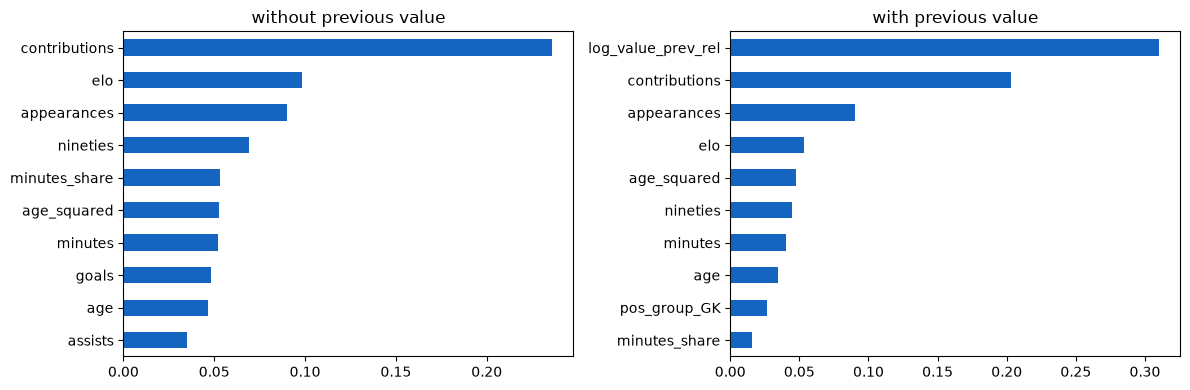

Look at the right panel. If log_value_prev dwarfs everything else,
that model is mostly copying last year's number forward.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, model, cols, title in [
    (axes[0], xgb_honest, cols_honest, "without previous value"),
    (axes[1], xgb_leaky,  cols_leaky,  "with previous value"),
]:
    imp = pd.Series(model.feature_importances_, index=cols).nlargest(10)
    imp.sort_values().plot(kind="barh", ax=ax, color="#1565c0")
    ax.set_title(title)
plt.tight_layout(); plt.show()

print("Look at the right panel. If log_value_prev dwarfs everything else,")
print("that model is mostly copying last year's number forward.")

## 6. Neural network

Regression this time, so one output and mean squared error rather than three
classes and cross entropy. Same small architecture for the same reason: a few
thousand rows does not support anything deep.

In [14]:
class ValueNet(nn.Module):
    def __init__(self, n_features, hidden=(128, 64), dropout=0.2):
        super().__init__()
        h1, h2 = hidden
        self.net = nn.Sequential(
            nn.Linear(n_features, h1), nn.BatchNorm1d(h1), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2), nn.BatchNorm1d(h2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_valuenet(data, epochs=400, lr=1e-3, patience=40, verbose=True):
    (X_tr, y_tr), (X_va, y_va), _ = data["train"], data["val"], data["test"]

    sc = StandardScaler().fit(X_tr)
    Xtr = torch.tensor(sc.transform(X_tr), dtype=torch.float32)
    Xva = torch.tensor(sc.transform(X_va), dtype=torch.float32)
    ytr = torch.tensor(y_tr, dtype=torch.float32)
    yva = torch.tensor(y_va, dtype=torch.float32)

    model = ValueNet(Xtr.shape[1])
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xtr, ytr), batch_size=128, shuffle=True)

    best, best_state, wait, history = np.inf, None, 0, []
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()

        model.eval()
        with torch.no_grad():
            tr_l = loss_fn(model(Xtr), ytr).item()
            va_l = loss_fn(model(Xva), yva).item()
        history.append((tr_l, va_l))

        if va_l < best - 1e-5:
            best, wait = va_l, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"  early stop at epoch {epoch}, val MSE {best:.4f}")
                break

    model.load_state_dict(best_state); model.eval()
    return model, sc, np.array(history)


net, net_scaler, net_history = train_valuenet(honest)

with torch.no_grad():
    X_te = torch.tensor(net_scaler.transform(honest["test"][0]), dtype=torch.float32)
    pred_net = net(X_te).numpy()

NET_HONEST = report(pred_net)
print(f"Neural network:  median error {NET_HONEST['median_ape']:.1%}   "
      f"within 25% {NET_HONEST['within_25pct']:.1%}   "
      f"log R2 {NET_HONEST['log_r2']:.3f}")

  early stop at epoch 91, val MSE 0.5692
Neural network:  median error 34.6%   within 25% 36.4%   log R2 0.657


## 7. Results

Read the two blocks separately. The honest block is the model that answers
"what is this player worth based on who they are and what they did". The
anchored block answers "how will Transfermarkt revise their own number", which
is a much easier question and a much less interesting one.

In [15]:
rows = [
    {"model": "xgboost, absolute target", "prev_value": "no", **XGB_ABSOLUTE},
    {"model": "lookup table (pos + age)", "prev_value": "no", **BASE},
    {"model": "ridge", "prev_value": "no", **RIDGE_HONEST},
    {"model": "xgboost", "prev_value": "no", **XGB_HONEST},
    {"model": "neural network", "prev_value": "no", **NET_HONEST},
    {"model": "ridge", "prev_value": "yes", **RIDGE_LEAKY},
    {"model": "xgboost", "prev_value": "yes", **XGB_LEAKY},
]
results = pd.DataFrame(rows)[
    ["model", "prev_value", "median_ape", "within_25pct", "within_50pct",
     "log_r2", "median_abs_error_eur"]
]
for c in ("median_ape", "within_25pct", "within_50pct"):
    results[c] = (results[c] * 100).round(1)
results["log_r2"] = results["log_r2"].round(3)
results["median_abs_error_eur"] = results["median_abs_error_eur"].map(M.euros)
results

,model,prev_value,median_ape,within_25pct,within_50pct,log_r2,median_abs_error_eur
0,"xgboost, absolute target",no,51.9,16.4,47.8,0.705,EUR 9.4m
1,lookup table (pos + age),no,51.1,26.6,48.9,0.253,EUR 9.1m
2,ridge,no,37.2,30.3,67.6,0.640,EUR 6.1m
3,xgboost,no,35.1,38.7,69.6,0.704,EUR 4.8m
4,neural network,no,34.6,36.4,69.7,0.657,EUR 5.5m
5,ridge,yes,25.2,49.7,82.5,0.728,EUR 4.2m
6,xgboost,yes,19.6,60.3,86.7,0.868,EUR 3.0m


In [16]:
# Did the inflation fix remove the systematic bias? A mean log error near
# zero means the model is no longer underpricing the whole test season.
for label, pred in [("absolute target (old)", pred_absolute),
                    ("relative target (new)", pred_honest)]:
    bias = (pred - TEST_LOG).mean()
    print(f"{label:24} mean log error {bias:+.3f}   "
          f"-> off by {np.exp(bias) - 1:+.0%} on average")

absolute target (old)    mean log error -0.669   -> off by -49% on average
relative target (new)    mean log error -0.066   -> off by -6% on average


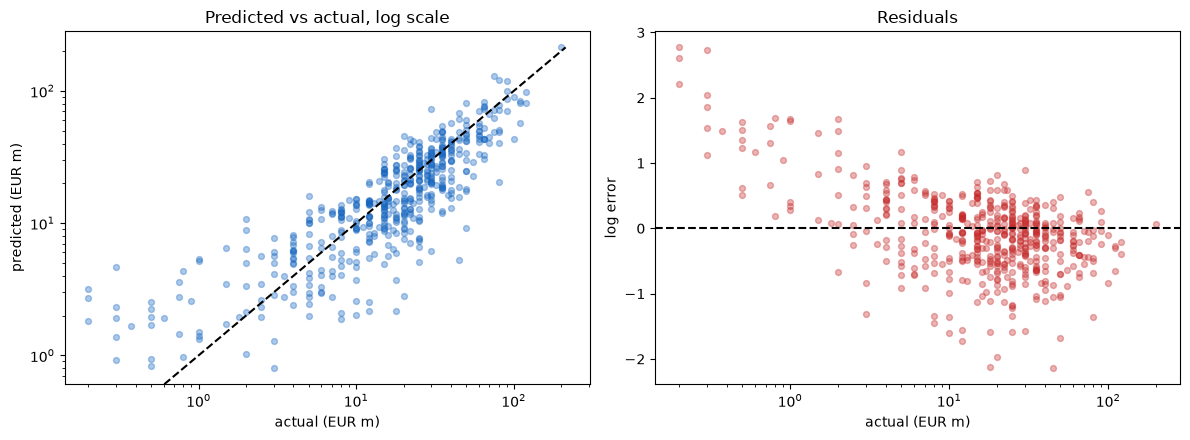

A tilt in the residuals means the model compresses toward the middle:
it underestimates the expensive players and overestimates the cheap ones.
That is normal for a regression on a skewed target and worth naming.


In [17]:
true = np.exp(TEST_LOG)
pred = np.exp(pred_honest)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(true / 1e6, pred / 1e6, alpha=0.35, s=18, color="#1565c0")
lim = max(true.max(), pred.max()) / 1e6
axes[0].plot([0, lim], [0, lim], "k--")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("actual (EUR m)"); axes[0].set_ylabel("predicted (EUR m)")
axes[0].set_title("Predicted vs actual, log scale")

resid = pred_honest - TEST_LOG
axes[1].scatter(true / 1e6, resid, alpha=0.35, s=18, color="#c62828")
axes[1].axhline(0, color="k", ls="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("actual (EUR m)"); axes[1].set_ylabel("log error")
axes[1].set_title("Residuals")
plt.tight_layout(); plt.show()

print("A tilt in the residuals means the model compresses toward the middle:")
print("it underestimates the expensive players and overestimates the cheap ones.")
print("That is normal for a regression on a skewed target and worth naming.")

### Where it goes most wrong

Worth reading the individual misses rather than only the aggregate. Large errors
usually cluster into recognisable groups: players who barely played, teenagers
valued on potential the model cannot see, and players whose value moved on
transfer speculation rather than performance.

In [18]:
inspect = test.copy()
inspect["predicted"] = np.exp(pred_honest)
inspect["error_pct"] = (inspect["predicted"] - inspect["market_value_eur"]) \
                       / inspect["market_value_eur"]

show = ["player", "club", "age", "minutes", "goals", "assists",
        "market_value_eur", "predicted", "error_pct"]

print("Most overvalued by the model:")
over = inspect.nlargest(8, "error_pct")[show].copy()
for c in ("market_value_eur", "predicted"):
    over[c] = over[c].map(M.euros)
over["error_pct"] = (over["error_pct"] * 100).round(0)
print(over.to_string(index=False))

print("\nMost undervalued by the model:")
under = inspect.nsmallest(8, "error_pct")[show].copy()
for c in ("market_value_eur", "predicted"):
    under[c] = under[c].map(M.euros)
under["error_pct"] = (under["error_pct"] * 100).round(0)
print(under.to_string(index=False))

Most overvalued by the model:
         player                   club       age  minutes  goals  assists market_value_eur predicted  error_pct
    Karl Darlow           Leeds United 35.624914     1980      0        0         EUR 200k  EUR 3.2m     1499.0
Mohamadou Kanté        West Ham United 20.673511       66      0        0         EUR 300k  EUR 4.6m     1443.0
   Kaden Rodney         Crystal Palace 21.242984        3      0        0         EUR 200k  EUR 2.7m     1260.0
  Ashley Barnes                Burnley 36.563997       41      0        0         EUR 200k  EUR 1.8m      817.0
   Harry Howell Brighton & Hove Albion 17.869952       93      0        0         EUR 300k  EUR 2.3m      675.0
 Séamus Coleman                Everton 37.615332       20      0        0         EUR 300k  EUR 1.9m      539.0
    Max Alleyne        Manchester City 20.492813      135      0        0         EUR 800k  EUR 4.3m      443.0
  Idrissa Gueye                Everton 36.577687     2102      2        3 

In [19]:
# Does playing time explain the misses?
inspect["abs_err"] = inspect["error_pct"].abs()
bands = pd.cut(inspect["minutes"], [0, 450, 900, 1800, 2700, 3420])
by_band = inspect.groupby(bands, observed=True)["abs_err"].agg(["median", "count"])
by_band["median"] = (by_band["median"] * 100).round(1)
print("Median absolute error by minutes played\n")
print(by_band.to_string())
print()
print("If error falls sharply as minutes rise, the model is fine and the")
print("problem is that bench players have no signal to predict from.")

Median absolute error by minutes played

              median  count
minutes                    
(0, 450]        57.8    119
(450, 900]      38.8     60
(900, 1800]     27.7    150
(1800, 2700]    23.7    104
(2700, 3420]    23.4     86

If error falls sharply as minutes rise, the model is fine and the
problem is that bench players have no signal to predict from.


## 8. Save, and feed it back into notebook 1

The valuation model is its own deliverable, but the more useful output right
now is the value table itself.

Notebook 1 scores player importance from minutes and goal involvements. Market
value is a better signal, because it already encodes reputation, potential and
position scarcity in a way that counting stats cannot. A 19 year old who played
600 minutes might be the most valuable asset at the club, and minutes alone
would rate them as a fringe player.

In [20]:
import json

sc_final = StandardScaler().fit(honest["train"][0])
torch.save(net.state_dict(), MODELS_DIR / "value_net.pt")
np.savez(MODELS_DIR / "value_net_scaler.npz",
         mean=net_scaler.mean_, scale=net_scaler.scale_)
xgb_honest.save_model(MODELS_DIR / "value_xgb.json")

meta = {
    "features": cols_honest,
    "test_season": f"{TEST_SEASON}/{(TEST_SEASON+1)%100:02d}",
    "xgb": {k: round(v, 4) for k, v in XGB_HONEST.items()},
    "net": {k: round(v, 4) for k, v in NET_HONEST.items()},
    "note": "trained without previous valuation; target is log value "
            "relative to the season market index",
    "market_index": {int(k): round(float(v), 4) for k, v in INDEX.items()},
}
(MODELS_DIR / "value_meta.json").write_text(json.dumps(meta, indent=2))
print("saved models")

saved models


In [21]:
from src.importance import build_importance_from_value

importance_v2 = build_importance_from_value(df)
print(f"{len(importance_v2):,} player seasons with value-based importance\n")

latest = int(importance_v2["season_start"].max())
team = importance_v2[importance_v2["season_start"] == latest]["team"].iloc[0]
print(f"{team}, {latest}/{(latest+1)%100:02d}")
importance_v2[
    (importance_v2["season_start"] == latest) & (importance_v2["team"] == team)
].nlargest(15, "importance")[
    ["player", "position", "minutes", "market_value_eur", "importance"]
]

7,165 player seasons with value-based importance

AFC Bournemouth, 2025/26


,player,position,minutes,market_value_eur,importance
6646,Antoine Semenyo,Attack,3205,75000000.0,0.975
6647,Djordje Petrovic,Goalkeeper,3420,28000000.0,0.882
6648,Adrien Truffert,Defender,3380,25000000.0,0.864
6649,Alex Scott,Midfield,2860,40000000.0,0.859
6650,Marcos Senesi,Defender,3290,22000000.0,0.838
6651,Evanilson,Attack,2762,35000000.0,0.832
6652,Marcus Tavernier,Midfield,2743,23000000.0,0.779
6653,Álex Jiménez,Defender,2327,22000000.0,0.725
6654,Junior Kroupi,Attack,1683,40000000.0,0.722
6655,Tyler Adams,Midfield,1779,25000000.0,0.677


In [22]:
# Compare the two importance signals on the same squad. Where they
# disagree is where the new one earns its place.
from src import importance as IMP

old = IMP.load_importance()
merged = old.merge(
    importance_v2[["season_start", "team", "player_key", "importance"]],
    on=["season_start", "team", "player_key"],
    suffixes=("_minutes", "_value"), how="inner")

merged["gap"] = merged["importance_value"] - merged["importance_minutes"]
recent = merged[merged["season_start"] >= latest - 1]

print("Rated much higher by market value than by minutes:")
print(recent.nlargest(8, "gap")[
    ["player", "team", "importance_minutes", "importance_value"]
].round(2).to_string(index=False))
print()
print("These are usually young players and squad rotation at big clubs.")
print("The news branch should treat them as more important than minutes")
print("alone would suggest, which is exactly the upgrade.")

Rated much higher by market value than by minutes:
            player              team  importance_minutes  importance_value
        Oscar Bobb            Fulham                0.10              0.72
             Rodri   Manchester City                0.01              0.56
         Leny Yoro Manchester United                0.23              0.75
   Albert Grønbaek       Southampton                0.03              0.55
        Marc Guéhi    Crystal Palace                0.46              0.98
     Tyler Dibling           Everton                0.06              0.58
       Axel Disasi       Aston Villa                0.09              0.61
Jarrad Branthwaite           Everton                0.15              0.67

These are usually young players and squad rotation at big clubs.
The news branch should treat them as more important than minutes
alone would suggest, which is exactly the upgrade.


## Where this leaves us

A valuation model, and a better importance signal that notebook 1 can use
immediately.

### To wire it into notebook 1

In the news branch, swap `IMP.build_importance()` for
`build_importance_from_value(df)`. Everything downstream is unchanged, because
both produce the same columns. The injured-striker logic gets sharper for free.

### Honest limitations

**Transfermarkt values are crowd estimates, not facts.** We are modelling an
opinion. When the model disagrees with Transfermarkt, neither side is
automatically wrong.

**Bench players are close to unpredictable.** Under about 500 minutes there is
barely any performance signal, and the value is mostly reputation and potential
that the features cannot see.

**The data ends in mid 2026.** That project's collection pipeline is paused, so
2026/27 squads are not covered and anyone signed recently is missing entirely.

**The market index is a straight line.** Inflation is assumed constant per
year in log space. It fits this data well, but a sudden market shock, like a new
broadcast deal, would break the extrapolation for a season.

**No expected goals.** The FBref scrape only offered basic stat types, so there
is no xG to join. Understat publishes player-season xG and would be the source
to add if you want it.

**Position grouping is coarse.** Four groups treats a holding midfielder and an
attacking midfielder identically, and the market does not. `sub_position` is in
the dataset if you want to try finer grouping.

### Next

Notebook 3, player replacement, which is mostly built already. The feature
table here is the similarity space: standardise the per-90 columns, compute
cosine distance within position group, and filter by value and age.